In [1]:
import pandas as pd
rep="/Volumes/BroadExt/sDrive/Recherche/Boye/HDR/Data/vlexique2.0.3/"
repOut=rep+"WordStructure/"
pd.__version__

'2.2.3'

In [2]:
# fParadigms="vlexique_paradigms.csv"
fParadigms="vlexique2.pkl"
fFeatures="vlexique_features.csv"
fLexemes="vlexique_lexemes.csv"
fTags="vlexique_tags.csv"
fCells="vlexique_cells.csv"

# dfParadigms=pd.read_csv(rep+fParadigms)
dfParadigms=pd.read_pickle(rep+fParadigms)
dfFeatures=pd.read_csv(rep+fFeatures)
dfLexemes=pd.read_csv(rep+fLexemes)
dfTags=pd.read_csv(rep+fTags)
dfCells=pd.read_csv(rep+fCells)

In [3]:
plages={"100":-1,"1.000":100,"10.000":1000,"100.000":10000,"1.000.000":100000,"10.000.000":1000000,
       "+":100000000}
vPlages=plages.values()
kPlages=list(plages.keys())
kPlages

['100', '1.000', '10.000', '100.000', '1.000.000', '10.000.000', '+']

In [4]:
dfParadigms.head()

,phono,lexeme,case,ortho,tir1
0,#DEF#,absoudre,ai1P,absolûmes,0
1,#DEF#,absoudre,ai1S,absolus,0
2,#DEF#,absoudre,ai2P,absolûtes,0
3,#DEF#,absoudre,ai2S,absolus,0
4,#DEF#,absoudre,ai3P,absolurent,0


In [5]:
dfParadigms["plage"]=pd.cut(dfParadigms.tir1,vPlages,labels=kPlages[:-1])
# dfParadigms["plage"]=dfParadigms.plage.astype(str)
# dfParadigms.plage

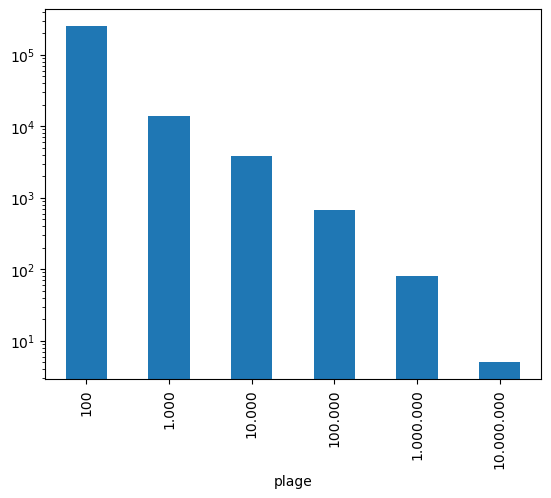

In [6]:
ax=dfParadigms.groupby("plage",observed=True)["lexeme"].count().plot(kind="bar")
ax.set_yscale('log')

In [7]:
dfTotal=dfParadigms[(dfParadigms.phono!="#DEF#")]
dfOutTot=dfTotal.groupby(["lexeme","case"])[["ortho","phono","tir1"]].agg({"ortho":list,"phono":list,"tir1":"sum"}).reset_index()
dfOutTot["ortho"]=dfOutTot["ortho"].str.join(",")
dfOutTot["phono"]=dfOutTot["phono"].str.join(",")
dfOutTot.to_pickle(repOut+"vlexique2-Total.pkl")
dfPivot=dfOutTot.pivot(index="lexeme",columns="case",values="phono")
dfPivot.to_csv(repOut+"vlexique2-Total.csv",sep=";",encoding="utf8")

In [8]:
dfSwim=dfParadigms[(dfParadigms.tir1>0) & (dfParadigms.phono!="#DEF#")]

la différence entre pd.cut et pd.qcut :
- pd.cut coupe en intervalles de largeurs identiques sur les valeurs
- pd.qcut coupe en intervalles identiques en population

In [9]:
dfSwim["Quant"]=pd.qcut(dfSwim.tir1,10,duplicates="drop",labels=range(9))
dfSwim

/var/folders/dy/h2nycthd7qjbd6qkb5h8t0nm0000gn/T/ipykernel_31697/836977963.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfSwim["Quant"]=pd.qcut(dfSwim.tir1,10,duplicates="drop",labels=range(9))


,phono,lexeme,case,ortho,tir1,plage,Quant
1209,2vr,oeuvrer,pI2S,œuvre,1,100,0
1210,2vr,oeuvrer,pi1S,œuvre,14,100,4
1211,2vr,oeuvrer,pi2S,œuvres,6,100,3
1212,2vr,oeuvrer,pi3P,œuvrent,45,100,6
1213,2vr,oeuvrer,pi3S,œuvre,66,100,6
...,...,...,...,...,...,...,...
269696,ôdyle,onduler,ppFP,ondulées,5,100,2
269697,ôdyle,onduler,ppFS,ondulée,3,100,1
269698,ôdyle,onduler,ppMP,ondulés,12,100,4
269699,ôdyle,onduler,ppMS,ondulé,18,100,5


<Axes: xlabel='Quant'>

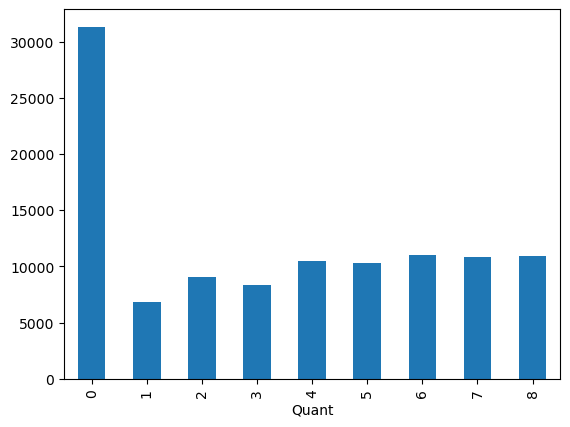

In [10]:
dfSwim.groupby("Quant",observed=True)["tir1"].count().plot(kind="bar")

In [11]:
for i in range(9):
    dfSelect=dfSwim.loc[dfSwim.Quant>=i,:]
    dfOutSel=dfSelect.groupby(["lexeme","case"])[["ortho","phono","tir1"]].agg({"ortho":list,"phono":list,"tir1":"sum"}).reset_index()
    dfOutSel["ortho"]=dfOutSel["ortho"].str.join(",")
    dfOutSel["phono"]=dfOutSel["phono"].str.join(",")
    dfOutSel.to_pickle(repOut+"vlexique2-S%d.pkl"%i)
    dfPivot=dfOutSel.pivot(index="lexeme",columns="case",values="phono")
    dfPivot.to_csv(repOut+"vlexique2-S%d.csv"%i,sep=";",encoding="utf8")
    if i<8:
        dfRest=dfSwim.loc[dfSwim.Quant<i+1,:]
        dfOutRest=dfRest.groupby(["lexeme","case"])[["ortho","phono","tir1"]].agg({"ortho":list,"phono":list,"tir1":"sum"}).reset_index()
        dfOutRest["ortho"]=dfOutRest["ortho"].str.join(",")
        dfOutRest["phono"]=dfOutRest["phono"].str.join(",")
        dfOutRest.to_pickle(repOut+"vlexique2-R%d.pkl"%(i+1))
        dfPivot=dfOutRest.pivot(index="lexeme",columns="case",values="phono")
        dfPivot.to_csv(repOut+"vlexique2-R%d.csv"%(i+1),sep=";",encoding="utf8")    

array([<Axes: title={'center': 'mean'}, xlabel='inflection_class'>,
       <Axes: title={'center': 'std'}, xlabel='inflection_class'>,
       <Axes: title={'center': 'sum'}, xlabel='inflection_class'>],
      dtype=object)

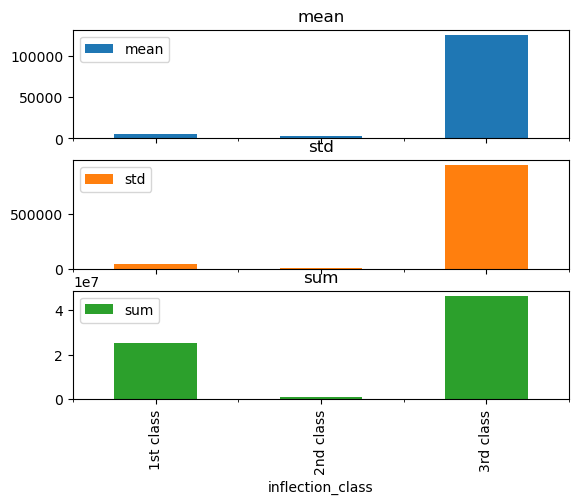

In [12]:
dfGroups=dfLexemes.groupby("inflection_class")["frequency"].agg([lambda x: int(x.mean()),lambda x: int(x.std()),"sum"])
dfGroups.columns=["mean","std","sum"]
dfGroups.plot(kind="bar",subplots=True)